# Time Iteration - Consumption Saving

Pablo Winant

## General Problem

We seek to solve numerically the following consumption-saving problem
using the time-iteration algorithm.

Income is an iid normally distributed process with standard deviation
$\sigma$. Interest rate is $r\in [1,\frac{1}{\beta}[$ where
$\beta\in]0,1[$ is the discount factor.

Available income is $w_t$ and follows the law of motion:

$$w_{t+1} = e^ {\epsilon_{t+1}} +  (w_{t} - c_{t}) r$$

where $c_t \in ]0,w_t]$ is consumption chosen at date $t$ (which
includes an implicit no borrowing constraint).

## Calibration

We will use the following calibration:

$\sigma = 0.01$

$\beta = 0.96$

$r = 1.03$

1.  **Choose a structure `model` to represent the model parameters.**

In [93]:
model = (;
    σ=0.01,
    β=0.96,
    r=1.03,
    γ=4.0
)

(σ = 0.01, β = 0.96, r = 1.03, γ = 4.0)

## Representing the decision function

The solution of the model is a decision rule $c(w)$.

In what follows, we will approximate it by a function defined over
$[0,w_{max}[$, pinned down by the values it takes on $N$ linearly spaced
grid points.

In our solutions algorithm, we will use the initial guess
$\varphi_0(w) = min(w, p_0+p_1(w-p_0))$.

1.  **Create a structure `approx` to represent the approximation space.
    This structure should contain the parameters, as well as a
    `points::Vector{Float64}` array coontaining the (regularly spaced)
    list of grid points.**

To start with you can take $w_{max}=5$, $N=20$, $p_0=0.95, p_1=0.03$ but
don’t hesitate to change these values later if needed.

In [62]:
approx = let
    N = 20
    wmin = 0.001
    wmax = 5
    points = [range(start=wmin, stop=wmax; length=N)...]
    (;
        N, wmin, wmax, points, p0=0.95, p1=0.03
    )
end

(N = 20, wmin = 0.001, wmax = 5, points = [0.001, 0.26410526315789473, 0.5272105263157895, 0.7903157894736842, 1.053421052631579, 1.3165263157894738, 1.5796315789473685, 1.8427368421052632, 2.1058421052631577, 2.3689473684210527, 2.632052631578947, 2.895157894736842, 3.1582631578947367, 3.4213684210526316, 3.684473684210526, 3.947578947368421, 4.210684210526316, 4.47378947368421, 4.736894736842105, 5.0], p0 = 0.95, p1 = 0.03)

1.  **Define a method `φ_0(w::Float64)::Float64` for the initial guess.
    Plot it against $w$ in the approximation space.**

In [63]:
φ_0(w) = min(w, 0.95 + 0.03*(w-0.95))

φ_0 (generic function with 1 method)

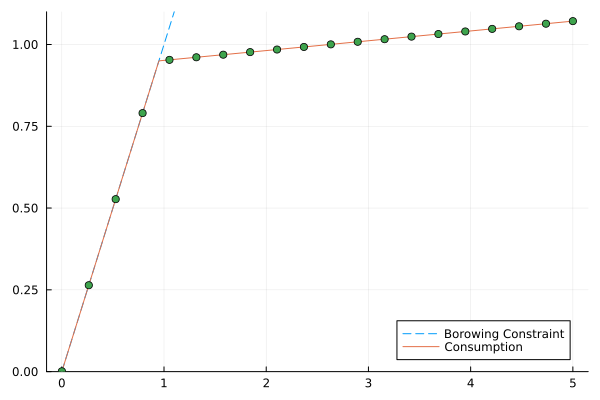

In [64]:
using Plots

xvec = range(start=approx.wmin, stop=approx.wmax; length=1000)
# yvec = [φ_0(x) for x in xvec]   # evaluate
yvec = φ_0.(xvec)   # evaluate
plot(xvec, xvec, label="Borowing Constraint", linestyle=:dash)
plot!(xvec, yvec, label="Consumption")
scatter!(points, φ_0.(points), label="")

ylims!(0, 1.1)



1.  **Compute the values `c_0::{Float64}`of `φ_0()` on the grid
    `points`**

In [65]:
c_0 = φ_0.(points);

1.  **Use the `Interpolations.jl` library to define a function
    `φ(w::Float64)` defined for any `w` using piecewise *linear*
    interpolation in such a way that it takes values `c_0` on the grid
    `points`.**

In [66]:
using Interpolations

φ = LinearInterpolation(approx.points, c_0; extrapolation_bc=Line());
# φ = CubicSplineInterpolation(approx.points, c_0;);


1.  **Create a single plot with**:

- the function `φ_0()`
- the interpolated function $φ$
- its values `c_0` on the grid points

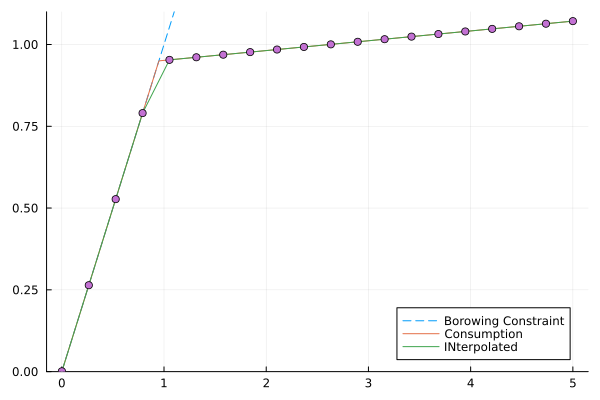

In [67]:
using Plots

xvec = range(start=approx.wmin, stop=approx.wmax; length=1000)
# yvec = [φ_0(x) for x in xvec]   # evaluate
yvec = φ_0.(xvec)   # evaluate
plot(xvec, xvec, label="Borowing Constraint", linestyle=:dash)
plot!(xvec, yvec, label="Consumption")
plot!(xvec, φ.(xvec), label="INterpolated")
scatter!(points, φ_0.(points), label="")


ylims!(0, 1.1)

1.  **Bonus: add to the graph the function obtained using cubic spline
    interpolation. What *could* be the problem?**

In [ ]:
# your code here

## Discretizing $\epsilon_{t+1}$

1.  **Represent the shock $\epsilon$ by two vectors $(e_1, ... e_q)$ and
    $(l_1, ..., l_q)$ with $q=10$ such that for a suitable function $g$
    we can approximate $E_{\epsilon} (g(\epsilon))$ by
    $\sum_{i=1}^q l_i e_i$ .**

(choose the method you want)

In [ ]:
using FastGaussQuadrature
e,l = gausshermite(10)


# renoramlize
e *= sqrt(2)*model.σ

l /= sqrt(pi)


10-element Vector{Float64}:
 4.31065263071828e-6
 0.0007580709343122154
 0.01911158050077043
 0.13548370298026785
 0.3446423349320186
 0.3446423349320186
 0.13548370298026785
 0.01911158050077043
 0.0007580709343122154
 4.31065263071828e-6

1.  **Test that it works by computing
    $E_{\epsilon} \left[ \epsilon^2 \right]$.**

In [85]:
f(u) = u^2
variance = ( sum( [f(a)*b for (a,b) in zip(e,l)] ) )
std = sqrt(variance)

0.010000000000000038

1.  **Redefine `approx` so as to include the discretized shock**

In [86]:
approx = merge(
    approx,
    (;
        e = e,
        l = l
    )
)

(N = 20, wmin = 0.001, wmax = 5, points = [0.001, 0.26410526315789473, 0.5272105263157895, 0.7903157894736842, 1.053421052631579, 1.3165263157894738, 1.5796315789473685, 1.8427368421052632, 2.1058421052631577, 2.3689473684210527, 2.632052631578947, 2.895157894736842, 3.1582631578947367, 3.4213684210526316, 3.684473684210526, 3.947578947368421, 4.210684210526316, 4.47378947368421, 4.736894736842105, 5.0], p0 = 0.95, p1 = 0.03, e = [-0.04859462828332312, -0.03581823483551927, -0.024843258416389527, -0.014659890943911626, -0.004849357075155013, 0.004849357075155013, 0.014659890943911626, 0.024843258416389527, 0.03581823483551927, 0.04859462828332312], l = [4.31065263071828e-6, 0.0007580709343122154, 0.01911158050077043, 0.13548370298026785, 0.3446423349320186, 0.3446423349320186, 0.13548370298026785, 0.01911158050077043, 0.0007580709343122154, 4.31065263071828e-6])

## Euler equation

1.  **Write down the Euler equation, paying attention to the slackness
    condition.**

It should be of the form
$$0 \leq \underbrace{E_t \left[ f(w_t, c_t, w_{t+1}, c_{t+1}, \epsilon_{t+1}) \right]}_{\Phi_t} \perp c_t \leq w_t$$

where $f$ is a function to be explicited.

$$0 \leq E_t\left[  1-\beta \left(\frac{c_{t+1}}{c_t}\right)^{-\gamma}  r\right] \perp c_t \leq w_t$$

1.  **Define the function
    `Phi(w::Float64,c::Float64,φ::Fun, model, approx)` which
    approximates the residuals of the euler equation given the available
    income today, the consumption choice today, the consumption
    *function* tomorrow and the model/approx structures.**

In [95]:
function Phi(w, c, φ, model, approx)
    # c: consumption today
    # φ: comnsumption policy () tomorrow
    
    (;r, γ, β) = model

    # # take ϵ as given
    # ϵ = 0.0

    # compute expectations:
    residual = 0.0

    # integrate over all epsilon values

    for (l, ϵ) in zip(approx.l, approx.e)

        # compute transition
        
        # -> available income
        W = exp(ϵ) + (w-c)*r

        # -> consumption tomorrow
        C = φ(W)
        res = (1-β*(C/c)^(-γ)*r)   # residual for a given value of epsilon

        residual += l*res

    end

    return residual

end

Phi (generic function with 1 method)

1.  **Overload `Phi` function with another method
    `Phi(w::Float64,c::Float64,φ::Fun, model, approx, slackness=true)`
    which uses the Fisher-Burmeister transform to incorporate the credit
    constraint.**

In [90]:
min(0.2, 0.4)

0.2

In [91]:
# we're going to use min() instead
# and define a function F instead of overloading Phi

F(w, c, φ, model, approx) = min(   Phi(w,c,φ, model, approx), w-c   )

F (generic function with 1 method)

1.  **Plot the optization residuals (i.e. values of $\Phi_t$)
    corresponding to the initial guess function with and without the
    complementarity constraints.**

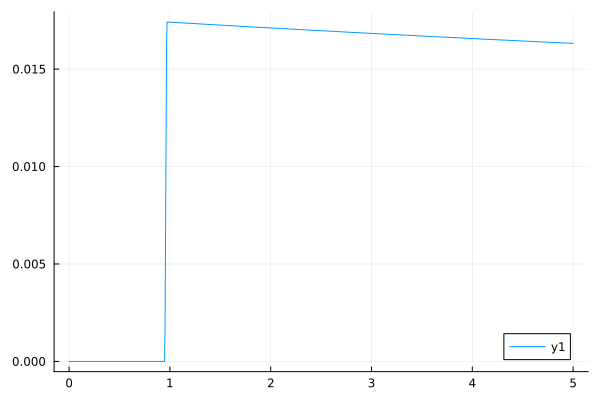

In [99]:
yvec = [F(
    w,
    φ_0(w),
    φ_0, # decision tomorrow
    model,
    approx,
    
)    
for w in xvec
]
plot(xvec, yvec)

## Time Iteration

1.  **(prep): Assuming the initial guess $φ_0()$ is the decision rule
    followed tomorrow, determine, for a given value `w` in the
    state-space, the optimal consumption choice made today. This can be
    achieved by feeding the appropriate function into the right
    nonlinear root-finder.**

In [102]:
using Roots

In [ ]:
w_ = 2

c_ = φ_0(w_) # initial guess
# solve for optimal choice at w_

# find the zero of function:

find_zero(
    u -> F(w_,u,φ_0, model,approx,),
    c_
)

0.9856170978039823

1.  **(prep): Find the vector of all the optimal consumption choices on
    the grid today, given the decision rule tomorrow.**

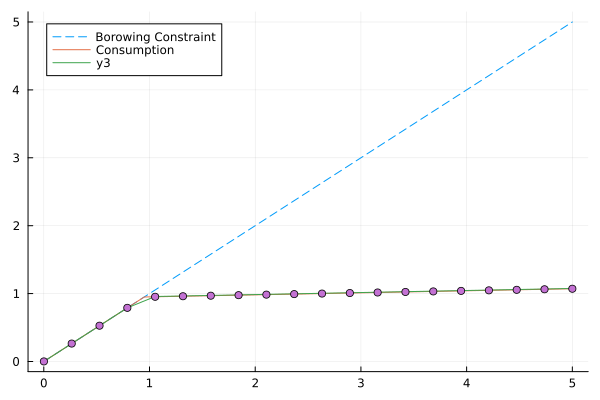

In [ ]:
c_optimal = [find_zero(
    u -> F(w_,u,φ_0, model,approx,),
    φ_0(w_)
) for w_ in approx.points]


# using Plots

# xvec = range(start=approx.wmin, stop=approx.wmax; length=1000)
# # yvec = [φ_0(x) for x in xvec]   # evaluate
# yvec = φ_0.(xvec)   # evaluate
# plot(xvec, xvec, label="Borowing Constraint", linestyle=:dash)
# plot!(xvec, yvec, label="Consumption")
# plot!(points, c_optimal)
# scatter!(points, φ_0.(points), label="")

    

1.  **Plot the optimization residuals (i.e. values of $\Phi_t$) for the
    initial guess function**

In [ ]:
# your code here

1.  **Write down the time-iteration algorithm.**

You can use the course as reference and/or repeat the recurrence steps
below:

- given an initial guess for the consumption vector `c0`
- create a function defined `φ` on `[0,wmax]` which interpolates `c0` on
  the grid
- for each grid point `w` in the grid, solve the system
  `u->Phi(w,u,φ, model, approx, slackness=true)`
  - store the result as a vector `c1`
- check whether `c1` is close to `c0`
  - yes: check the system is indeed solved and return
  - no: start again with `c1` as `c0`

In [117]:
# here is a placeholder implementation to help you structure your program.
#  feel free to modify or discard


"""
φ: Float64->Float64 Initial guess for the consumption function
model: parameters representing the model
approx: parameters defining the approximation and solution method
K: max number of iterations
... other parameters for you to choose
"""
function time_iteration(φ0, model, approx; K=200, τ=1e-8 )

    # ...

    # convert initial function φ0 into a consumption vector by evaluating φ on the grid
    # c0 = ... :: Vector{Float64}
    c0 = φ0.(approx.points)

    for k=1:K

        # convert consumption vector c0 into a function φ
        φ = LinearInterpolation(approx.points, c0; extrapolation_bc=Line());


        # solve for the optimal consumption for all grid points
        # ...

        c1 = [find_zero(
            u -> F(w_,u,φ, model,approx,),
            φ(w_)
        ) for w_ in approx.points]


        # c1  :: Vector{Float64}

        # check distance between c0 and c1

        η = maximum(abs, c1-c0)
        @show (k, η)
        if η<τ
            return φ
        end

        c0 = c1

    end




end

time_iteration

In [119]:
sol = time_iteration(φ_0,  model, approx)

(k, η) = (1, 0.004284480879369612)
(k, η) = (2, 0.004169471406446856)
(k, η) = (3, 0.0040570990243951055)
(k, η) = (4, 0.003947329945144018)
(k, η) = (5, 0.0038401290979939162)
(k, η) = (6, 0.003735460266789614)
(k, η) = (7, 0.0036332862202335114)
(k, η) = (8, 0.0035335688354722894)
(k, η) = (9, 0.0034362692151170826)
(k, η) = (10, 0.0033413477978687656)
(k, η) = (11, 0.0032487644628920176)
(k, η) = (12, 0.0031584786281790844)
(k, η) = (13, 0.00307044934304046)
(k, η) = (14, 0.002984635374944533)
(k, η) = (15, 0.002900995290916697)
(k, η) = (16, 0.0028194875336451375)
(k, η) = (17, 0.0027400704925957253)
(k, η) = (18, 0.002662702570236153)
(k, η) = (19, 0.002587342243598245)
(k, η) = (20, 0.002513948121426468)
(k, η) = (21, 0.002442478997063402)
(k, η) = (22, 0.002372893897265138)
(k, η) = (23, 0.0023051521271530984)
(k, η) = (24, 0.0022392133114970125)
(k, η) = (25, 0.002175037432496918)
(k, η) = (26, 0.0021125848642471468)
(k, η) = (27, 0.0020518164040568276)
(k, η) = (28, 0.00199269

20-element extrapolate(interpolate((::Vector{Float64},), ::Vector{Float64}, Gridded(Linear())), Line()) with element type Float64:
 0.001
 0.26410526315789473
 0.5272105263157895
 0.7903157894736842
 1.0014227558248991
 1.0328424513841206
 1.0535156981345364
 1.0703222082933932
 1.085074654246884
 1.0985338126439381
 1.1110970218468281
 1.1230004065563644
 1.134396828537712
 1.1453914666329246
 1.1560600661682872
 1.166459137927015
 1.1766320465921056
 1.1866128406786858
 1.196428766578507
 1.2061019781715463

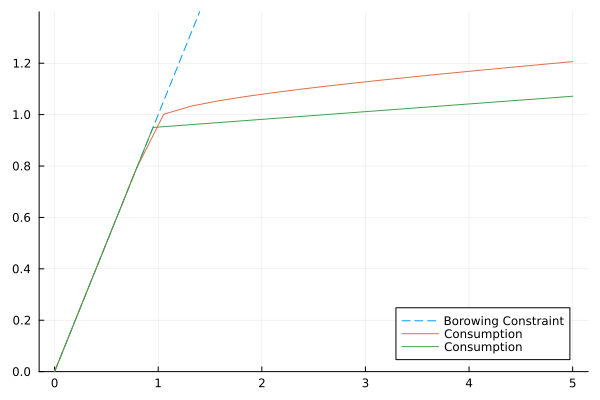

In [123]:

xvec = range(start=approx.wmin, stop=approx.wmax; length=1000)
# yvec = [φ_0(x) for x in xvec]   # evaluate
yvec = φ_0.(xvec)   # evaluate
plot(xvec, xvec, label="Borowing Constraint", linestyle=:dash)
plot!(xvec, sol.(xvec), label="Consumption")
plot!(xvec, φ_0.(xvec), label="Consumption")
ylims!(0, 1.4)

# plot!(points, c_optimal)

# scatter!(points, φ_0.(points), label="")

In [116]:
sol  =time_iteration(φ_0, model, approx)

(k, η) = (1, 0.004284480879369612)
(k, η) = (2, 0.004169471406446856)
(k, η) = (3, 0.0040570990243951055)
(k, η) = (4, 0.003947329945144018)
(k, η) = (5, 0.0038401290979939162)
(k, η) = (6, 0.003735460266789614)
(k, η) = (7, 0.0036332862202335114)
(k, η) = (8, 0.0035335688354722894)
(k, η) = (9, 0.0034362692151170826)
(k, η) = (10, 0.0033413477978687656)
(k, η) = (11, 0.0032487644628920176)
(k, η) = (12, 0.0031584786281790844)
(k, η) = (13, 0.00307044934304046)
(k, η) = (14, 0.002984635374944533)
(k, η) = (15, 0.002900995290916697)
(k, η) = (16, 0.0028194875336451375)
(k, η) = (17, 0.0027400704925957253)
(k, η) = (18, 0.002662702570236153)
(k, η) = (19, 0.002587342243598245)
(k, η) = (20, 0.002513948121426468)
(k, η) = (21, 0.002442478997063402)
(k, η) = (22, 0.002372893897265138)
(k, η) = (23, 0.0023051521271530984)
(k, η) = (24, 0.0022392133114970125)
(k, η) = (25, 0.002175037432496918)
(k, η) = (26, 0.0021125848642471468)
(k, η) = (27, 0.0020518164040568276)
(k, η) = (28, 0.00199269

20-element Vector{Float64}:
 0.001
 0.26410526315789473
 0.5272105263157895
 0.7903157894736842
 1.0014227558249043
 1.0328424513841972
 1.0535156981349898
 1.0703222082950783
 1.085074654251868
 1.09853381265678
 1.111097021876943
 1.123000406622253
 1.1343968286743
 1.1453914669039678
 1.156060066686848
 1.1664591388885228
 1.1766320483266375
 1.1866128437320107
 1.1964287718353184
 1.2061019870393253

1.  **Check that the value returned by `time_iteration` is actually a
    solution to the system. How fast is the convergence? Graphical
    representation.**

In [ ]:
# your code here

## Bonuses

1.  **(easy): perform some sensitivity analysis on the model to explain
    the effect of the main parameters**

In [ ]:
# your code here

1.  **(medium): Give the solution to the above problem, simulate the law
    of motion for the available income. Find a way to plot the
    distriution of that income over a long period of time.**

2.  **(hard): Propose and implement some ideas to speed up the solution
    process.**

One promising avenue consists in solving for all consumption values at
all grid points as one single system of equation after recognizing that
the jacobian of this particular system has a specific structure.